# <span style="color:orange;">Barreras a la formación</span>

<span style="font-size:15px; color:green;"><b>Encuesta Anual Laboral (EAL) 2022–2024</b></span>

### Evolución 2022-2024 e implicaciones para la toma de decisiones

---

## 1. Introducción

**Objetivo.** Identificar qué barreras limitan la formación en empresas de **más de 500 trabajadores**, cómo han evolucionado entre 2022 y 2024, y qué cambios son lo bastante fiables como para actuar sobre ellos.

**Pregunta de negocio.** ¿Cómo podríamos ajustar nuestras políticas de formación para alinearlas con las tendencias del sector - en competencias clave, medios utilizados y barreras más comunes - y aumentar así el impacto del desarrollo profesional en la organización? Este notebook responde a la parte de **barreras**, para una empresa de más de 500 trabajadores.

**Alcance.** Fuente: Encuesta Anual Laboral (EAL), Ministerio de Trabajo y Economía Social, ediciones 2022-2024. Se trabaja sobre el corte de empresas de **más de 499 trabajadores** (hoja EAL-24, empresas que sí forman) - el desglose más cercano al perfil de la organización.

**Limitaciones.**
- Las empresas que **no** forman (hoja EAL-25) solo se desglosan en "hasta 49" y "50 o más" trabajadores - no existe el corte de +500. Se usan únicamente como referencia puntual (sección 3.5), dejando claro que la comparación no es exacta.
- Los resultados son agregados publicados por el Ministerio (porcentajes), no microdatos - el detalle de esta limitación y cómo se sortea para el contraste estadístico se explica en la sección 3.3.
- El valor de 2023 se incluye explícitamente en la evolución y en el contraste estadístico (sección 3.2.2), no solo como referencia lateral.

### 1.1 Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

from statsmodels.stats.proportion import proportions_ztest
from matplotlib.lines import Line2D

COLOR_ACENTO = "#2E5F8A"
COLOR_NEUTRO = "#B5B9BF"
COLOR_TEXTO = "#26303A"
plt.rcParams["axes.edgecolor"] = "#D0D3D8"
plt.rcParams["font.size"] = 11

---
## 2. Preparación de datos

### 2.1 Importación

Cada hoja del Excel (`EAL-24` para empresas formadoras, `EAL-25` para no formadoras) apila varias subtablas con la misma estructura para distintos recortes: total nacional, tramos de tamaño, y sector. La posición exacta cambia ligeramente de un año a otro, así que cada bloque se localiza buscando su título, no una fila fija.

Los bloques usados son:
- **`EAL-24c`** - *"Empresas de más de 499 trabajadores que proporcionaron formación..."* → nuestro foco principal.
- **`EAL-25b`** - *"Empresas de 50 o más trabajadores que no proporcionaron formación..."* → único corte de tamaño disponible para no formadoras, usado solo como referencia (sección 3.5).

In [13]:
RUTA_DATOS = r"..\Data\Encuesta_EAL\Raw_2022-2024"

RUTA_ARCHIVOS = {
    2022: fr"{RUTA_DATOS}\Tablas_EAL_2022.xlsx",
    2023: fr"{RUTA_DATOS}\Tablas_EAL_2023.xlsx",
    2024: fr"{RUTA_DATOS}\Tablas_EAL_2024.xlsx",
}


def leer_filas(ruta, hoja):
    '''Lee una hoja completa como lista de tuplas (una por fila).'''
    libro = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    return list(libro[hoja].iter_rows(values_only=True))


def extraer_bloque(filas, etiqueta_inicio):
    '''Extrae los motivos y sus porcentajes (Nada/Poco/Bastante/Mucho) del
    bloque cuyo título contiene `etiqueta_inicio`. Lanza un error explícito
    si el bloque no se encuentra, en vez de devolver None silenciosamente
    (evita un TypeError poco informativo más adelante si cambia el layout
    del Excel de un año a otro).'''
    idx_inicio = next(
        (i for i, fila in enumerate(filas)
         if fila and isinstance(fila[0], str) and etiqueta_inicio in fila[0]),
        None,
    )
    if idx_inicio is None:
        raise ValueError(f"No se encontró ningún bloque con la etiqueta '{etiqueta_inicio}'")

    idx_header = next(
        (i for i in range(idx_inicio, min(idx_inicio + 10, len(filas)))
         if len(filas[i]) > 2 and filas[i][1] == "TOTAL" and filas[i][2] == "NADA"),
        None,
    )
    if idx_header is None:
        raise ValueError(f"Se encontró el bloque '{etiqueta_inicio}' pero no su fila de cabecera (TOTAL/NADA)")

    motivos = []
    for fila in filas[idx_header + 1:]:
        primera = fila[0] if fila else None
        if primera is None:
            break
        if isinstance(primera, str) and primera.strip().startswith("EAL-"):
            break
        if len(fila) < 6 or fila[1] is None:
            continue
        motivos.append({
            "motivo_original": primera.strip(),
            "nada": fila[2], "poco": fila[3], "bastante": fila[4], "mucho": fila[5],
        })
    return motivos

In [14]:
registros = []
for anio, ruta in RUTA_ARCHIVOS.items():
    filas_formadoras = leer_filas(ruta, "EAL-24")
    for motivo in extraer_bloque(filas_formadoras, "MÁS DE 499 TRABAJADORES"):
        registros.append({"anio": anio, "grupo": "Formadoras_+500", **motivo})

    filas_no_formadoras = leer_filas(ruta, "EAL-25")
    for motivo in extraer_bloque(filas_no_formadoras, "50 O MÁS TRABAJADORES"):
        registros.append({"anio": anio, "grupo": "No_formadoras_50mas", **motivo})

df_barreras = pd.DataFrame(registros)
print(f"Registros extraídos: {len(df_barreras)}")
df_barreras.head()

Registros extraídos: 59


,anio,grupo,motivo_original,nada,poco,bastante,mucho
0,2022,Formadoras_+500,El nivel de formación de los empleados era el ...,14.123,35.676,44.575,5.626
1,2022,Formadoras_+500,La estrategia preferida de la empresa fue cont...,16.417,46.069,31.678,5.836
2,2022,Formadoras_+500,Dificultad para evaluar la necesidades de form...,30.037,58.049,10.432,1.482
3,2022,Formadoras_+500,La falta de cursos de formación adecuados en e...,26.826,56.381,15.109,1.683
4,2022,Formadoras_+500,El alto coste de los cursos de formación,16.703,47.515,29.362,6.421


### 2.2 Limpieza y transformación

**Decisión 1 - Unificar el nombre de los motivos entre años.** El mismo motivo se redacta de forma distinta según la edición (p. ej. *"la estrategia preferida de la empresa fue contratar personal..."* en 2022 frente a *"la empresa prefirió contratar a personal..."* en 2023). Se normaliza por palabras clave a un código estable, para poder comparar 2022-2024 sin que un cambio de redacción rompa la serie.

**Decisión 2 - Métrica única: "Bastante + Mucho".** El grado de limitación real de una barrera son las empresas que la puntúan alto; "Nada"/"Poco" no interesan para priorizar acciones. Se calcula `bastante_mucho` como métrica de referencia en todo el notebook.

**Decisión 3 - Tres motivos sin serie completa 2022-2024** (`Otras_Razones` y `Preferencia_Contrato_Formativo_Dual`, sin dato en 2022; `Cancelacion_COVID`, sin dato en 2023 ni 2024 al dejar de preguntarse tras la pandemia) se excluyen de la evolución por motivo y del contraste estadístico (secciones 3.2.2 y 3.3), en vez de tratarlos como 0. De los **11 motivos codificados**, quedan **8 con serie completa 2022-2024** para esos análisis.

In [15]:
REGLAS_NORMALIZACION = [
    ("Nivel_Formacion_Adecuado", ["nivel de formaci", "apropiado"]),
    ("Preferencia_Contratar_Cualificados", ["contratar", "cualificaci"]),
    ("Dificultad_Evaluar_Necesidades", ["dificultad para evaluar"]),
    ("Falta_Cursos_Adecuados", ["falta de cursos"]),
    ("Alto_Coste_Cursos", ["alto coste"]),
    ("Preferencia_Contrato_Formativo_Dual", ["contrato de formaci", "contratos formativos", "dual"]),
    ("Esfuerzo_Previo_Suficiente", ["mayor esfuerzo realizado"]),
    ("Carga_Trabajo_Tiempo", ["carga de trabajo", "tiempo disponible"]),
    ("Dificultad_Ayudas_Subvenciones", ["ayudas o subvenciones"]),
    ("Cancelacion_COVID", ["covid"]),
    ("Otras_Razones", ["otras razones"]),
]

NOMBRES_CORTOS = {
    "Nivel_Formacion_Adecuado": "Nivel de formación ya adecuado",
    "Preferencia_Contratar_Cualificados": "Prefiere contratar cualificados",
    "Dificultad_Evaluar_Necesidades": "Dificultad para evaluar necesidades",
    "Falta_Cursos_Adecuados": "Cursos inadecuados",
    "Alto_Coste_Cursos": "Coste formación",
    "Preferencia_Contrato_Formativo_Dual": "Prefieren contratos prácticas",
    "Esfuerzo_Previo_Suficiente": "Cursos previos suficientes",
    "Carga_Trabajo_Tiempo": "Carga de trabajo / falta de tiempo",
    "Dificultad_Ayudas_Subvenciones": "Complejidad ayudas",
    "Otras_Razones": "Otras razones",
    "Cancelacion_COVID": "Cancelación/aplazamiento por COVID",
}


def normalizar_motivo(texto):
    texto_normalizado = texto.lower()
    for codigo, palabras_clave in REGLAS_NORMALIZACION:
        if any(palabra in texto_normalizado for palabra in palabras_clave):
            return codigo
    return "OTRO_NO_MAPEADO"


df_barreras["motivo"] = df_barreras["motivo_original"].apply(normalizar_motivo)
df_barreras["bastante_mucho"] = df_barreras["bastante"] + df_barreras["mucho"]

sin_mapear = df_barreras.loc[df_barreras["motivo"] == "OTRO_NO_MAPEADO", "motivo_original"].unique()
print(f"Motivos sin mapear: {len(sin_mapear)}")

suma_check = df_barreras["nada"] + df_barreras["poco"] + df_barreras["bastante"] + df_barreras["mucho"]
print(f"Filas con suma fuera de [99,101]: {((suma_check < 99) | (suma_check > 101)).sum()}")

Motivos sin mapear: 0
Filas con suma fuera de [99,101]: 0


---
## 3. RESULTADOS

### 3.1 Las barreras más frecuentes en 2024 (empresas +500 trabajadores)

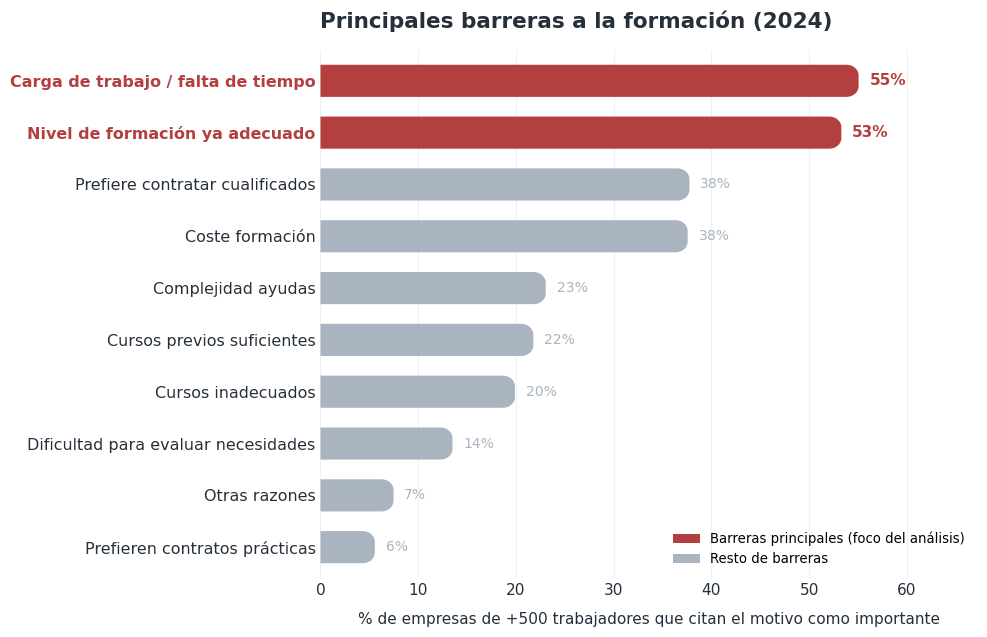

In [16]:
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch as LegendPatch

COLOR_DESTACADO = "#B33F3F"   # rojo/vino: para las 1-2 barreras en foco
COLOR_NEUTRO_RANKING = "#A9B4C0"  # azul-gris apagado: el resto, sin protagonismo


def crear_barra_horizontal_redondeada(ax, y_centro, longitud, alto, color, radio_pixeles=14):
    '''Barra horizontal (desde x=0 hasta x=longitud) con esquinas redondeadas
    solo en el extremo derecho.'''
    x0, x1 = 0, longitud
    y0, y1 = y_centro - alto / 2, y_centro + alto / 2

    origen_display = ax.transData.transform((0, 0))
    origen_data = ax.transData.inverted().transform(origen_display)
    punto_x = ax.transData.inverted().transform(origen_display + np.array([radio_pixeles, 0]))
    punto_y = ax.transData.inverted().transform(origen_display + np.array([0, radio_pixeles]))
    radio_x = min(abs(punto_x[0] - origen_data[0]), longitud)
    radio_y = min(abs(punto_y[1] - origen_data[1]), alto / 2)
    kappa = 0.5522847498

    vertices = [
        (x0, y0),
        (x1 - radio_x, y0),
        (x1 - radio_x + kappa * radio_x, y0),
        (x1, y0 + radio_y - kappa * radio_y),
        (x1, y0 + radio_y),
        (x1, y1 - radio_y),
        (x1, y1 - radio_y + kappa * radio_y),
        (x1 - radio_x + kappa * radio_x, y1),
        (x1 - radio_x, y1),
        (x0, y1),
        (x0, y0),
        (x0, y0),
    ]
    codigos = [
        Path.MOVETO, Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.LINETO, Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(vertices, codigos), facecolor=color, edgecolor="none", linewidth=0, zorder=3))


MOTIVOS_DESTACADOS = ["Carga_Trabajo_Tiempo", "Nivel_Formacion_Adecuado"]

ranking_2024 = (
    df_barreras[(df_barreras["anio"] == 2024) & (df_barreras["grupo"] == "Formadoras_+500")]
    .sort_values("bastante_mucho", ascending=True)
    .reset_index(drop=True)
)
ranking_2024["destacado"] = ranking_2024["motivo"].isin(MOTIVOS_DESTACADOS)
ranking_2024["color"] = ranking_2024["destacado"].map({True: COLOR_DESTACADO, False: COLOR_NEUTRO_RANKING})

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

y_pos = np.arange(len(ranking_2024))
valor_max = ranking_2024["bastante_mucho"].max()
ax.set_xlim(0, valor_max * 1.22)
ax.set_ylim(-0.6, len(ranking_2024) - 0.4)

etiquetas_y = ranking_2024["motivo"].map(lambda m: NOMBRES_CORTOS.get(m, m))
ax.set_yticks(y_pos)
ax.set_yticklabels(etiquetas_y, fontsize=11.5, color=COLOR_TEXTO)
# Negrita solo para las categorías destacadas
for tick_label, destacado in zip(ax.get_yticklabels(), ranking_2024["destacado"]):
    tick_label.set_fontweight("bold" if destacado else "normal")
    tick_label.set_color(COLOR_DESTACADO if destacado else COLOR_TEXTO)

plt.tight_layout()
fig.canvas.draw()

for i, fila in ranking_2024.iterrows():
    crear_barra_horizontal_redondeada(ax, i, fila["bastante_mucho"], alto=0.62, color=fila["color"], radio_pixeles=12)
    ax.text(
        fila["bastante_mucho"] + valor_max * 0.02, i, f"{fila['bastante_mucho']:.0f}%",
        va="center", fontsize=11 if fila["destacado"] else 10,
        fontweight="bold" if fila["destacado"] else "normal",
        color=fila["color"],
    )

ax.set_xlabel("% de empresas de +500 trabajadores que citan el motivo como importante",
              fontsize=11, color=COLOR_TEXTO, labelpad=10)
ax.set_title("Principales barreras a la formación (2024)",
             fontsize=15.5, fontweight="bold", color=COLOR_TEXTO, loc="left", pad=16)

ax.grid(axis="x", linestyle="-", linewidth=0.8, alpha=0.6, color="#E4E7EB", zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0, colors=COLOR_TEXTO)

leyenda = [
    LegendPatch(facecolor=COLOR_DESTACADO, label="Barreras principales (foco del análisis)"),
    LegendPatch(facecolor=COLOR_NEUTRO_RANKING, label="Resto de barreras"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=9.5)

plt.tight_layout()
plt.show()

**Lo que esto significa para el negocio:** en una empresa grande, la formación no falla por falta de interés en la formación, falla por dificultad **logística**. 
La carga de trabajo y la falta de tiempo (55%) es la barrera más citada, seguida muy de cerca por la percepción de que el nivel formativo ya es suficiente (53%). 
Son las dos únicas barreras que superan la mitad de las empresas; el resto queda muy por debajo (≤38%).

### 3.2 Evolución 2022-2024 de las barreras principales

Se define aquí, una única vez, la lista de barreras principales que se reutiliza más adelante (sección 3.4):

In [17]:
MOTIVOS_PRINCIPALES = ["Carga_Trabajo_Tiempo", "Nivel_Formacion_Adecuado",
                       "Preferencia_Contratar_Cualificados", "Alto_Coste_Cursos"]

### 3.2.1 Vista simplificada (exploratoria): agrupación en 4 categorías

Antes del detalle por motivo, se probó agrupar 9 de los 11 motivos codificados (se excluyen `Cancelacion_COVID` y `Otras_Razones`, que no encajan en ninguna dimensión) en 4 categorías más amplias (tiempo/organización, coste, oferta, percepción), para ver si simplificaba la lectura.

**Aviso:** esta agrupación es una clasificación **propia**, no oficial de la EAL, y **se descarta como base de conclusiones** - al promediar, diluye la señal más importante del análisis (que dos motivos concretos, no una categoría entera, dominan claramente sobre el resto). Se muestra aquí solo como vista exploratoria; el análisis real se apoya en la sección 3.2.2.

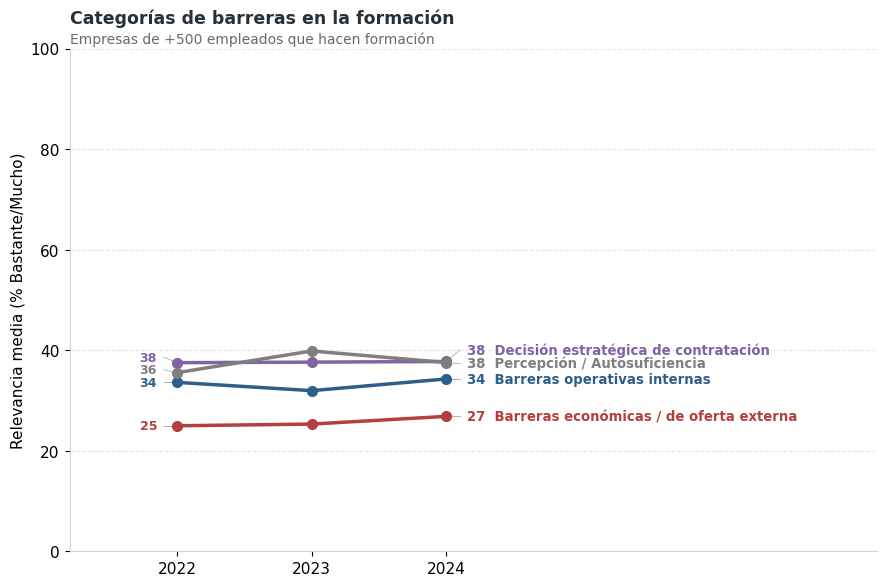

In [18]:
MAPA_DIMENSIONES = {
    "Nivel_Formacion_Adecuado": "Percepción / Autosuficiencia",
    "Esfuerzo_Previo_Suficiente": "Percepción / Autosuficiencia",
    "Preferencia_Contratar_Cualificados": "Decisión estratégica de contratación",
    "Preferencia_Contrato_Formativo_Dual": "Decisión estratégica de contratación",
    "Carga_Trabajo_Tiempo": "Barreras operativas internas",
    "Dificultad_Evaluar_Necesidades": "Barreras operativas internas",
    "Alto_Coste_Cursos": "Barreras económicas / de oferta externa",
    "Falta_Cursos_Adecuados": "Barreras económicas / de oferta externa",
    "Dificultad_Ayudas_Subvenciones": "Barreras económicas / de oferta externa",
}
COLORES_DIMENSION = {
    "Barreras operativas internas": "#2E5F8A",
    "Barreras económicas / de oferta externa": "#B33F3F",
    "Decisión estratégica de contratación": "#8064A2",
    "Percepción / Autosuficiencia": "#7F7F7F",
}


def separar_etiquetas(valores, separacion_minima):
    '''Ajusta posiciones Y para que ninguna etiqueta quede a menos de
    separacion_minima de la siguiente, preservando el orden relativo.'''
    orden = np.argsort(valores)
    ajustadas = np.array(valores, dtype=float)
    for i in range(1, len(orden)):
        actual, anterior = orden[i], orden[i - 1]
        if ajustadas[actual] - ajustadas[anterior] < separacion_minima:
            ajustadas[actual] = ajustadas[anterior] + separacion_minima
    return ajustadas


datos_dim = df_barreras[
    (df_barreras["grupo"] == "Formadoras_+500") & (df_barreras["motivo"].isin(MAPA_DIMENSIONES))
].copy()
datos_dim["dimension"] = datos_dim["motivo"].map(MAPA_DIMENSIONES)

pivote_dim = datos_dim.pivot_table(index="motivo", columns="anio", values="bastante_mucho")
motivos_completos_dim = pivote_dim.dropna().index.tolist()

evolucion_dimension = (
    datos_dim[datos_dim["motivo"].isin(motivos_completos_dim)]
    .groupby(["dimension", "anio"])["bastante_mucho"].mean()
    .unstack("anio")
)

etiquetas_2022 = separar_etiquetas(evolucion_dimension[2022].values, separacion_minima=2.5)
etiquetas_2024 = separar_etiquetas(evolucion_dimension[2024].values, separacion_minima=2.5)

fig, ax = plt.subplots(figsize=(9, 6))
for (dimension, fila), y22_etq, y24_etq in zip(evolucion_dimension.iterrows(), etiquetas_2022, etiquetas_2024):
    color = COLORES_DIMENSION.get(dimension, "#333333")
    ax.plot(fila.index, fila.values, marker="o", linewidth=2.5, color=color, markersize=7, zorder=3)
    ax.plot([2021.9, 2022], [y22_etq, fila[2022]], color=color, linewidth=0.7, alpha=0.5, zorder=1)
    ax.plot([2024, 2024.1], [fila[2024], y24_etq], color=color, linewidth=0.7, alpha=0.5, zorder=1)
    ax.text(2021.85, y22_etq, f"{fila[2022]:.0f}", ha="right", va="center", fontsize=9, fontweight="bold", color=color)
    ax.text(2024.15, y24_etq, f"{fila[2024]:.0f}  {dimension}", ha="left", va="center", fontsize=9.5, fontweight="bold", color=color)

ax.set_xlim(2021.2, 2027.2)
ax.set_ylim(0, 100)
ax.set_xticks([2022, 2023, 2024])
ax.set_ylabel("Relevancia media (% Bastante/Mucho)")
ax.set_title("Categorías de barreras en la formación",
              fontsize=12.5, fontweight="bold", color=COLOR_TEXTO, loc="left", pad=18)
ax.text(0, 1.01, "Empresas de +500 empleados que hacen formación", transform=ax.transAxes,
        fontsize=10, color="dimgray", ha="left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Lectura de esta vista exploratoria:** las 4 categorías quedan agrupadas entre 25 y 38 (escala 0-100), casi planas los tres años - confirma que la agrupación no revela nada que el detalle por motivo (sección 3.2.2) no muestre mejor. No se usa para ninguna conclusión de este notebook.

### 3.2.2 Evolución por motivo individual

Los **8 motivos con serie completa 2022-2024** (de los 11 codificados; ver Decisión 3 en la sección 2.2), sin agrupar, con los **3 años representados**. Cada tramo se traza por separado según si ese cambio concreto es estadísticamente fiable.

In [19]:
N_MUESTRA_500MAS = {2022: 1613, 2023: 1878, 2024: 1992}


def test_diferencia_proporciones(pct_a, n_a, pct_b, n_b):
    conteos = [round(pct_a * n_a / 100), round(pct_b * n_b / 100)]
    _, p_valor = proportions_ztest(conteos, [n_a, n_b])
    return p_valor


def clasificar_patron(fila, tramos_sig):
    cambios_fiables = [fila[b] - fila[a] for (a, b), sig in tramos_sig.items() if sig]
    if not cambios_fiables:
        return "Sin cambio", "#A9B4C0"
    signos = set(np.sign(c) for c in cambios_fiables)
    if len(signos) > 1:
        return "Oscila", "#B8860B"
    elif list(signos)[0] > 0:
        return "Crece", "#2E7D46"
    else:
        return "Decrece", "#B33F3F"


evolucion_todos = (
    df_barreras[df_barreras["grupo"] == "Formadoras_+500"]
    .pivot_table(index="motivo", columns="anio", values="bastante_mucho")
    .dropna()
)

significacion_tramos = {}
for motivo, fila in evolucion_todos.iterrows():
    significacion_tramos[motivo] = {
        (2022, 2023): test_diferencia_proporciones(fila[2022], N_MUESTRA_500MAS[2022], fila[2023], N_MUESTRA_500MAS[2023]) < 0.05,
        (2023, 2024): test_diferencia_proporciones(fila[2023], N_MUESTRA_500MAS[2023], fila[2024], N_MUESTRA_500MAS[2024]) < 0.05,
    }

patrones = {motivo: clasificar_patron(fila, significacion_tramos[motivo]) for motivo, fila in evolucion_todos.iterrows()}

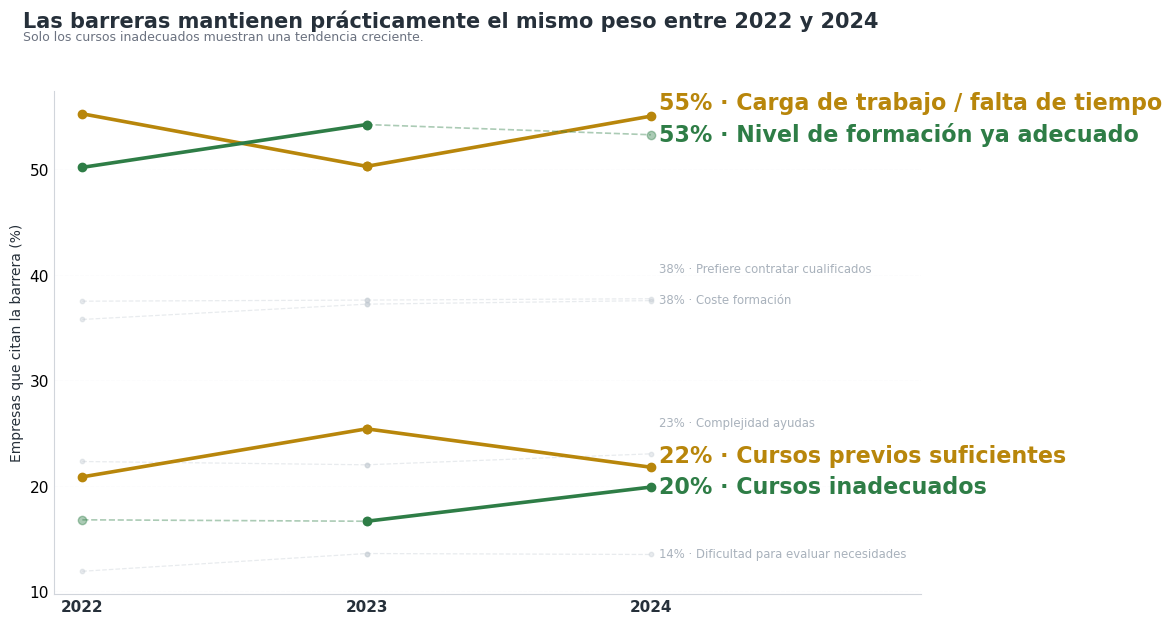

In [20]:
evolucion_todos["destacado"] = [
    patrones[m][0] != "Sin cambio"
    for m in evolucion_todos.index
]


evolucion_todos = evolucion_todos.sort_values(
    by=2024,
    ascending=False
)


etiquetas_y = separar_etiquetas(
    evolucion_todos[2024].values[::-1],
    separacion_minima=3
)[::-1]


fig, ax = plt.subplots(figsize=(10.2, 6.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Barreras sin cambios significativos
for (motivo, fila), y in zip(evolucion_todos.iterrows(), etiquetas_y):

    if fila["destacado"]:
        continue

    for a, b in [(2022, 2023), (2023, 2024)]:

        ax.plot(
            [a, b],
            [fila[a], fila[b]],
            color="#BFC7CF",
            linewidth=0.9,
            linestyle="--",
            marker="o",
            markersize=3.2,
            alpha=0.35,
            zorder=1,
        )

    nombre = NOMBRES_CORTOS.get(motivo, motivo)

    ax.text(
        2024.03,
        y,
        f"{fila[2024]:.0f}% · {nombre}",
        fontsize=8.4,
        color="#A9B2BC",
        va="center",
    )

# Barreras con cambios significativos

for (motivo, fila), y in zip(evolucion_todos.iterrows(), etiquetas_y):

    if not fila["destacado"]:
        continue

    _, color = patrones[motivo]

    for a, b in [(2022, 2023), (2023, 2024)]:

        significativo = significacion_tramos[motivo][(a, b)]

        ax.plot(
            [a, b],
            [fila[a], fila[b]],
            color=color,
            linewidth=2.6 if significativo else 1.2,
            linestyle="-" if significativo else "--",
            marker="o",
            markersize=6,
            alpha=1 if significativo else 0.40,
            zorder=3,
        )

    nombre = NOMBRES_CORTOS.get(motivo, motivo)

    ax.text(
        2024.03,
        y,
        f"{fila[2024]:.0f}% · {nombre}",
        fontsize=16,
        color=color,
        fontweight="semibold",
        va="center",
    )


ax.set_xlim(2021.9, 2024.95)

ax.set_xticks([2022, 2023, 2024])

ax.set_xticklabels(
    [2022, 2023, 2024],
    fontsize=11,
    fontweight="bold",
    color=COLOR_TEXTO,
)

ax.set_ylabel(
    "Empresas que citan la barrera (%)",
    fontsize=10,
    color=COLOR_TEXTO,
)

fig.suptitle(
    "Las barreras mantienen prácticamente el mismo peso entre 2022 y 2024",
    fontsize=15,
    fontweight="bold",
    color=COLOR_TEXTO,
    x=0.08,
    ha="left",
)

fig.text(
    0.08,
    0.935,
    "Solo los cursos inadecuados muestran una tendencia creciente.",
    fontsize=9,
    color="#6B7280",
    ha="left",
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.08,
    color="#D9DEE5",
)

ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D1D5DB")
ax.spines["bottom"].set_color("#D1D5DB")

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.subplots_adjust(
    top=0.86,
    bottom=0.12,
    left=0.11,
    right=0.96,
)

plt.show()

Interpretación:

Con un marco de periodo tan pequeño es difícil decretar tendencias fuertes cuando los cambios son pequeños o muy graduales. No obstante, se observa:

Las barreras se organizan en tres niveles claros de importancia: dos **muy importantes** (>50%: "falta de tiempo" y "ya formamos bastante"), dos de importancia **media** (35-38%: "contratar, no formar" y "coste alto"), y cuatro de importancia **menor** (<25%). Esta jerarquía se mantiene igual los tres años - no cambia qué preocupa más a las empresas grandes.

Dentro de esa jerarquía estable, sí hay movimiento real año a año. "Falta de tiempo" baja de forma significativa en 2022-2023 y vuelve a subir de forma igual de significativa en 2023-2024, pero el balance se compensa: acaba prácticamente donde empezó. Lo mismo ocurre con "ya nos esforzamos". Solo una barrera, **"falta de oferta formativa adecuada"**, tiene una subida sostenida y real en el periodo.

De los 16 cambios de un año a otro comprobados, la mayoría (10 de 16) podrían deberse simplemente al azar de la muestra - solo destacamos como reales los 6 que superan esa prueba (sección 3.3).

**En una frase:** estable en el ranking, pero no estático en el detalle.

---

### 3.3 ¿Qué cambios son estadísticamente significativos?

Antes de determinar la prioridad de las barreras, hay que saber si un cambio entre años es una tendencia real o si cabe dentro del ruido propio de una encuesta muestral. Se aplica un **test Z de diferencia de dos proporciones** a cada tramo del periodo (2022→2023 y 2023→2024) por separado, no solo al cambio neto entre extremos - así se detectan oscilaciones intermedias que un único contraste 2022-2024 pasaría por alto (ver el caso de "Carga de trabajo/falta de tiempo" en la sección 3.2.2).

**Por qué este test y no otro:** es la comprobación estándar para responder "¿es distinto este porcentaje de aquel otro, o podría deberse al azar de la muestra?" - exactamente lo que necesitamos, ni más ni menos.

**Dato que lo hace posible:** el informe metodológico de la EAL publica el tamaño de muestra por tramo de empresa. Para el tramo de +499 trabajadores: **1.613 empresas en 2022, 1.878 en 2023 y 1.992 en 2024** - al ser el tamaño exacto de este tramo (no una aproximación agregada), el test es directamente fiable, sin las salvedades que suelen acompañar a este tipo de cálculo.

**Independencia de las muestras entre años.** El informe metodológico estandarizado de la EAL (MITES) confirma dos cosas relevantes para este test:
1. Para el tramo de +499 trabajadores la investigación es **exhaustiva** (censo, no muestreo) - prácticamente todas las empresas de ese tramo se incluyen cada año, no una submuestra aleatoria de una población mayor.
2. La muestra se selecciona cada edición mediante **muestreo sistemático con arranque aleatorio**, re-extraído del directorio de empresas de la Seguridad Social en cada año de referencia - no es un panel que reentreviste a las mismas empresas año a año.

Esto respalda tratar 2022, 2023 y 2024 como muestras (en la práctica, casi censos) independientes entre sí, que es el supuesto que necesita el test Z de dos proporciones. ([Informe metodológico estandarizado EAL](https://www.mites.gob.es/estadisticas/EAL/EAL2024/Informe_Metodologico_Estandarizado.pdf), apdo. 13.1.)

**Matiz pendiente:** se hacen 16 tests Z sobre el mismo conjunto de datos sin corrección por comparaciones múltiples. Con 16 tests a α=0,05 sin corregir, cabría esperar de media <1 falso positivo por azar - el bloque de 6 cambios significativos no se explica por esto solo, pero dos de ellos (`Nivel_Formacion_Adecuado` en 2022→2023, p=0,017, y `Falta_Cursos_Adecuados` en 2023→2024, p=0,0098) no sobrevivirían a una corrección de Bonferroni (umbral ≈0,003). Vale la pena tenerlo en cuenta como matiz de confianza en la conclusión 2 de la sección 4, sin que invalide el resultado.

In [21]:
filas_significacion = []
for motivo, fila in evolucion_todos.iterrows():
    for a, b in [(2022, 2023), (2023, 2024)]:
        p_valor = test_diferencia_proporciones(fila[a], N_MUESTRA_500MAS[a], fila[b], N_MUESTRA_500MAS[b])
        filas_significacion.append({
            "motivo": motivo, "periodo": f"{a}→{b}",
            f"%_inicio": round(fila[a], 1), "%_fin": round(fila[b], 1),
            "diferencia_pp": round(fila[b] - fila[a], 1),
            "p_valor": round(p_valor, 4), "significativo": p_valor < 0.05,
        })

tabla_significacion = pd.DataFrame(filas_significacion).sort_values("p_valor")
tabla_significacion

,motivo,periodo,%_inicio,%_fin,diferencia_pp,p_valor,significativo
10,Esfuerzo_Previo_Suficiente,2022→2023,20.9,25.4,4.6,0.0015,True
1,Carga_Trabajo_Tiempo,2023→2024,50.3,55.1,4.8,0.0031,True
0,Carga_Trabajo_Tiempo,2022→2023,55.3,50.3,-5.0,0.0033,True
11,Esfuerzo_Previo_Suficiente,2023→2024,25.4,21.8,-3.6,0.0081,True
13,Falta_Cursos_Adecuados,2023→2024,16.7,19.9,3.2,0.0098,True
2,Nivel_Formacion_Adecuado,2022→2023,50.2,54.3,4.1,0.0171,True
14,Dificultad_Evaluar_Necesidades,2022→2023,11.9,13.6,1.7,0.1398,False
6,Alto_Coste_Cursos,2022→2023,35.8,37.2,1.5,0.3756,False
9,Dificultad_Ayudas_Subvenciones,2023→2024,22.0,23.0,1.0,0.4343,False
3,Nivel_Formacion_Adecuado,2023→2024,54.3,53.3,-1.0,0.5550,False


**Lo que esto significa para el negocio:** al mirar cada tramo por separado, salen a la luz **6 cambios fiables** que la comparación de extremos ocultaba en su mayoría: los dos tramos de "Carga de trabajo/falta de tiempo" (baja y luego sube, ambos p<0,01), los dos tramos de "Esfuerzo previo ya suficiente" (sube y luego baja, ambos p<0,01), la subida de "Nivel de formación ya adecuado" en 2022→2023 (p=0,017) y la subida de "Falta de cursos adecuados" en 2023→2024 (p=0,010, la única que también era visible en el contraste neto 2022-2024). El resto de tramos no se puede distinguir del ruido muestral. Conclusión: **sí hay movimiento real año a año**, pero en las barreras principales tiende a compensarse, no a acumularse en una tendencia sostenida.

### 3.4 Referencia: empresas no formadoras (50 o más trabajadores)

**Importante:** esta comparación es solo orientativa. Las empresas no formadoras no se desglosan por el tramo de +500 - el corte disponible más cercano es "50 o más trabajadores", que mezcla empresas medianas y grandes. No es la misma población que el resto del notebook.

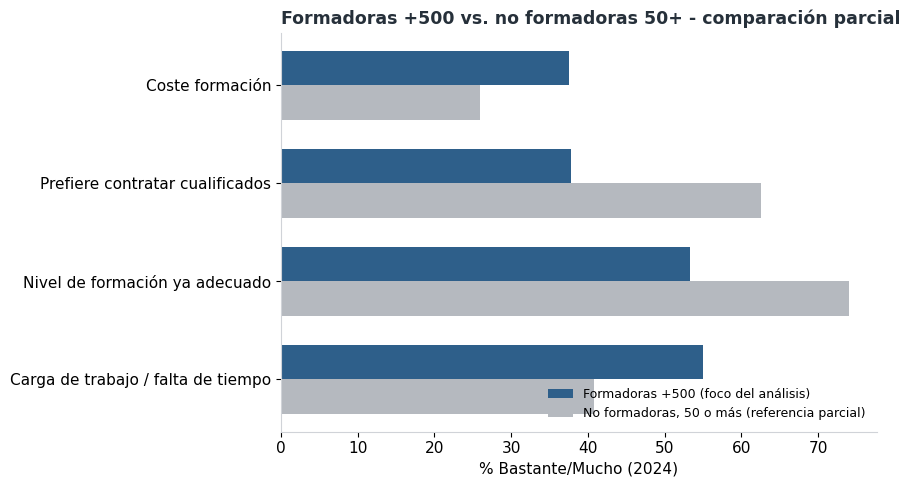

In [22]:
comparacion = (
    df_barreras[(df_barreras["anio"] == 2024) & (df_barreras["motivo"].isin(MOTIVOS_PRINCIPALES))]
    .pivot_table(index="motivo", columns="grupo", values="bastante_mucho")
    .loc[MOTIVOS_PRINCIPALES]
)

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(comparacion))
ancho = 0.35

ax.barh(y_pos + ancho / 2, comparacion["Formadoras_+500"], height=ancho, color=COLOR_ACENTO, label="Formadoras +500 (foco del análisis)")
ax.barh(y_pos - ancho / 2, comparacion["No_formadoras_50mas"], height=ancho, color=COLOR_NEUTRO, label="No formadoras, 50 o más (referencia parcial)")

ax.set_yticks(y_pos)
ax.set_yticklabels([NOMBRES_CORTOS[m] for m in comparacion.index])
ax.set_xlabel("% Bastante/Mucho (2024)")
ax.set_title("Formadoras +500 vs. no formadoras 50+ - comparación parcial", fontsize=12.5, fontweight="bold", color=COLOR_TEXTO, loc="left")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Lo que esto significa para el negocio (con la reserva ya indicada):** las empresas que no forman se apoyan mucho más en "contratar personal ya cualificado" como sustituto de la formación (63% frente al 38% de las formadoras). Es una diferencia grande, pero dado que las poblaciones no son estrictamente comparables, se toma como contexto, no como evidencia dura.

---
## 4. Conclusiones

**¿Qué barreras son más importantes?** Se organizan en tres niveles, estables durante todo el periodo:
- **Muy importantes (>50%):** falta de tiempo, y la percepción de que ya se forma bastante.
- **Importancia media (35-38%):** preferir contratar personal ya cualificado en vez de formar, y el alto coste de los cursos.
- **Importancia menor (<25%):** dificultad para acceder a ayudas, esfuerzo previo suficiente, falta de oferta adecuada, y dificultad para evaluar necesidades.

**¿Cuáles han cambiado?** El ranking en sí no cambia, pero dentro de él hay tres patrones distintos de movimiento real:
- **Oscilan sin tendencia neta:** "falta de tiempo" y "cursos previos suficientes" suben y bajan de forma significativa entre 2022, 2023 y 2024, pero acaban donde empezaron.
- **Sube y se mantiene:** "ya formamos bastante" tuvo una subida real en 2022-2023 (50%→54%) que no ha revertido desde entonces - no es ruido, es un nuevo nivel estable.
- **Tendencia reciente:** "falta de oferta adecuada" no cambió en 2022-2023, pero sí subió de forma real en 2023-2024 - es la única con una tendencia que sigue activa en el tramo más reciente, no solo un movimiento ya cerrado.

**¿Qué es estadísticamente significativo?** 6 de los 16 cambios de un año a otro comprobados (2 en carga de trabajo, 2 en cursos previos suficientes, 1 en nivel de formación adecuado, 1 en falta de oferta); el resto no se puede distinguir del ruido muestral.

**¿Qué debería tener en cuenta una empresa grande para planificar su política de formaciones?**

1. **Tener en cuenta estas barreras al planificar la política de formación**: como empresa española de +500 trabajadores, es razonable esperar que la propia plantilla presente un perfil de barreras similar al del sector - falta de tiempo y la percepción de que "ya formamos bastante" como obstáculos principales, seguidos de la preferencia por contratar en vez de formar y el coste de los cursos. Diseñar la política asumiendo estas barreras desde el inicio, en vez de descubrirlas sobre la marcha, permite anticipar soluciones concretas: formación integrada en el puesto y en microsesiones (en vez de cursos adicionales sobre una agenda ya saturada), y una revisión de los medios/canales disponibles para compensar la falta de tiempo - no solo confiar en la formación externa tradicional. Además, como la carga de trabajo oscila de forma real año a año (sección 3.3) y no de forma estable, conviene revisarla anualmente, no solo cada varios años, para no confundir una foto puntual con la tendencia real.

2. **Anticipar que la sensación de "ya formamos bastante" puede no reflejar la realidad - y que ya subió una vez de forma real** (2022-2023, no ha bajado desde entonces). Antes de asumirla como diagnóstico propio, conviene contrastarla con datos objetivos de brecha de competencias.

3. **Vigilar si la oferta formativa del mercado también encaja para nuestro perfil** - es la única barrera con tendencia sostenida al alza en el sector; si afecta también a nuestra empresa, refuerza el caso de invertir en formación interna en vez de depender de proveedores externos.
4. **No sobreinterpretar variaciones puntuales propias, igual que no se sobreinterpretan las del sector** - la mayoría de cambios año a año no superan la prueba estadística; conviene aplicar el mismo criterio de cautela a los propios datos de RRHH antes de actuar sobre una variación aislada.
